In [1]:
import numpy as np
import pandas as pd

In [2]:
customer_df=pd.read_csv("clean_df.csv")

In [3]:
customer_df.head()

,customer_unique_id,total_spend,total_freight_paid,total_payment,n_orders,total_distinct_products,avg_review_score,avg_installments,customer_state
0,0000366f3b9a7992bf8c76cfdf3221e2,129.90,12.00,141.90,1,1.0,5.0,8.0,SP
1,0000b849f77a49e4a4ce2b2a4ca5be3f,18.90,8.29,27.19,1,1.0,4.0,1.0,SP
2,0000f46a3911fa3c0805444483337064,69.00,17.22,86.22,1,1.0,3.0,8.0,SC
3,0000f6ccb0745a6a4b88665a16c9f078,25.99,17.63,43.62,1,1.0,4.0,4.0,PA
4,0004aac84e0df4da2b147fca70cf8255,180.00,16.89,196.89,1,1.0,5.0,6.0,SP


# Scale and Transform

In [4]:
from sklearn.preprocessing import RobustScaler

# Select features to cluster on (drop identifiers, categorical state, and near-constant columns)
feature_cols = ["total_spend", "total_freight_paid", "total_payment", 
                 "avg_review_score", "avg_installments"]

X = customer_df[feature_cols]

# Scale
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

# Keep as a DataFrame with column names, for later inspection of cluster centers
X_scaled_df = pd.DataFrame(X_scaled, columns=feature_cols, index=customer_df.index)

print(X_scaled_df.shape)
X_scaled_df.describe()

(93357, 5)


,total_spend,total_freight_paid,total_payment,avg_review_score,avg_installments
count,93357.000000,93357.000000,93357.000000,93357.000000,93357.000000
mean,0.484795,0.519379,0.480492,-0.840857,0.299921
std,2.013960,1.989553,1.893846,1.277782,0.891967
min,-0.829599,-1.537118,-0.821674,-4.000000,-0.666667
25%,-0.392624,-0.308297,-0.374226,-1.000000,-0.333333
50%,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.607376,0.691703,0.625774,0.000000,0.666667
max,124.652661,155.227948,113.441841,0.000000,7.333333


# Find K using elbow-method

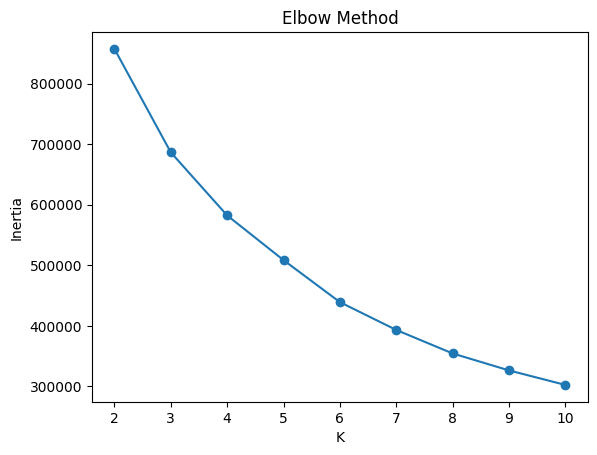

In [5]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertias = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled_df)
    inertias.append(km.inertia_)

plt.plot(K_range, inertias, marker='o')
plt.xlabel("K")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [6]:
from sklearn.metrics import silhouette_score

for k in [3, 4, 5, 6]:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled_df)
    score = silhouette_score(X_scaled_df, labels, sample_size=10000, random_state=42)
    print(f"K={k}: silhouette = {score:.4f}")

K=3: silhouette = 0.5402
K=4: silhouette = 0.4004
K=5: silhouette = 0.4093
K=6: silhouette = 0.4115


### K=3 aligning with both the strongest silhouette score and your prior EDA finding.

# Fit Model

In [7]:
from sklearn.cluster import KMeans

# Fit final model with chosen K
kmeans_final = KMeans(n_clusters=3, random_state=42, n_init=10)
customer_df["cluster"] = kmeans_final.fit_predict(X_scaled_df)

# Profile each cluster
cluster_profile = customer_df.groupby("cluster")[
    ["total_spend", "total_freight_paid", "total_payment", 
     "avg_review_score", "avg_installments"]
].mean()

cluster_sizes = customer_df["cluster"].value_counts().sort_index()

print(cluster_sizes)
cluster_profile

cluster
0    80145
1     1144
2    12068
Name: count, dtype: int64


,total_spend,total_freight_paid,total_payment,avg_review_score,avg_installments
cluster,,,,,
0,89.250666,18.370846,107.643282,4.198003,2.538155
1,1477.119781,99.805603,1577.236364,3.947067,6.278120
2,362.822628,50.692585,413.575780,3.921172,4.980992
